In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
orders = pd.read_excel("../data/orders.xlsx")
products = pd.read_excel("../data/products.xlsx")
sales = orders.merge(products, on="product_id")

In [5]:
sales.sample()

,order_id,accepted_at,product_id,quantity,regular_price,price,cost_price,level1,level2,name
683,1517616507,2022-01-13 20:42:12,981,1,119,119,69,Безалкогольные напитки,Напитки,Напиток Fanta


In [6]:
order_summary = (
    sales
    .groupby('order_id')
    .apply(
        lambda x: pd.Series({
            'total_quantity': x['quantity'].sum(),
            'total_revenue': (x['quantity'] * x['price']).sum(),
            'total_cost': (x['quantity'] * x['cost_price']).sum(),
            'average_price': x['price'].mean(),
            'max_price': x['price'].max(),
            'min_price': x['price'].min(),
            'number_of_products': x['product_id'].nunique(),
            'discount_amount': (
                (x['regular_price'] - x['price']) * x['quantity']
            ).sum(),
            'has_promo': (
                (x['price'] < x['regular_price']).any()
            ),
            'promo_quantity': (
                x.loc[x['price'] < x['regular_price'], 'quantity'].sum()
            ),
        })
    )
    .reset_index()
)

order_summary.sample(3)

,order_id,total_quantity,total_revenue,total_cost,average_price,max_price,min_price,number_of_products,discount_amount,has_promo,promo_quantity
34,1517370863,5,785,455,157.000000,359,27,5,140,True,2
158,1517469469,16,2419,1510,156.666667,363,69,15,304,True,8
109,1517432513,12,1657,990,129.444444,239,37,9,82,True,4


#### Average order value

In [7]:
order_summary['total_revenue'].mean()

np.float64(825.8835489833641)

#### Daily margin

In [8]:
total_margin = pd.Series({
    'RUB': (order_summary['total_revenue'] - order_summary['total_cost']).sum(),
    '%': (order_summary['total_revenue'] - order_summary['total_cost']).sum() * 100 / order_summary['total_revenue'].sum()
})

total_margin

RUB    168395.00000
%          37.68887
dtype: float64

In [9]:
margin_by_category = (
    sales
    .groupby('level1')
    .apply(
        lambda x: pd.Series({
            'RUB': (x['price'] - x['cost_price']).sum(),
            '%': (x['price'] - x['cost_price']).sum() * 100 / x['price'].sum()
        })
    )
    .sort_values(by='RUB', ascending=False)
)
margin_by_category.sample(3)

,RUB,%
level1,,
Замороженная продукция,11057.0,47.424405
Детство (Гигиена и Уход),517.0,29.901677
Сыры,6984.0,37.487923


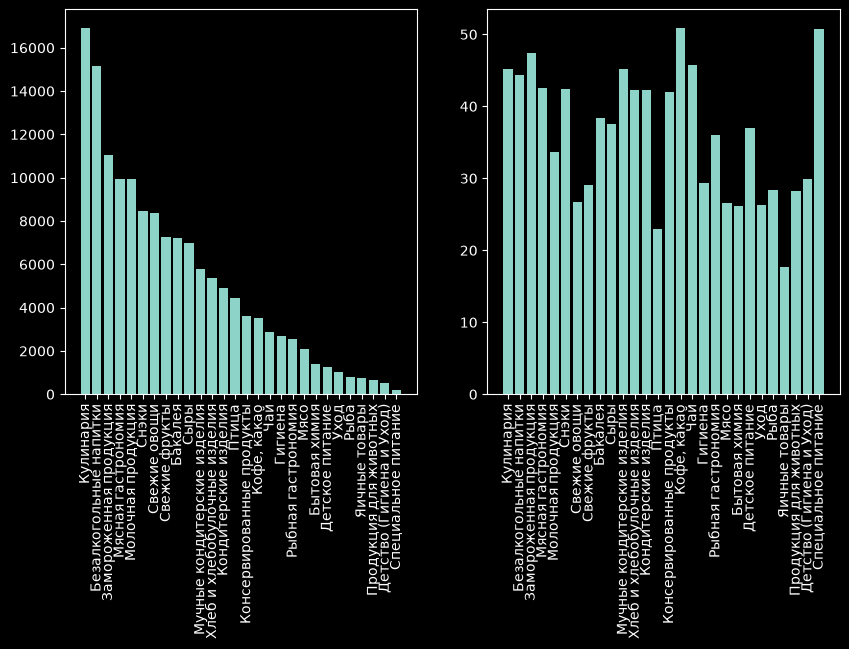

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for column, ax in zip(margin_by_category.columns, axes):
    ax.bar(margin_by_category.index, margin_by_category[column])
    ax.tick_params(axis='x', rotation=90)


#### Share of promotional sales

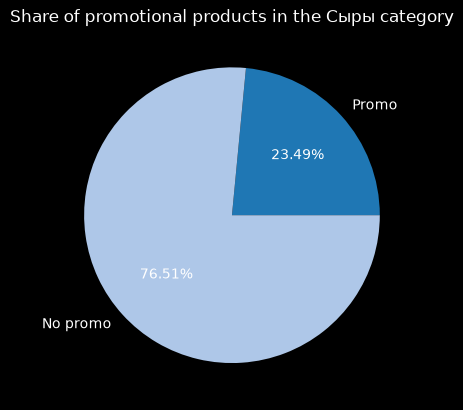

In [32]:
category_name = 'Сыры'
category_data = sales[sales['level1'] == category_name]

has_promo = category_data['price'] < category_data['regular_price']
promo_quantity = category_data.loc[has_promo, 'quantity'].sum()
total_quantity = category_data['quantity'].sum()

promo_share = pd.Series({
    'Promo': promo_quantity,
    'No promo': total_quantity
})

fig, ax = plt.subplots()

ax.pie(
    promo_share,
    labels= promo_share.index,
    autopct=lambda pct: f"{pct:.2f}%",
    colors=plt.cm.tab20(range(2))
)
ax.set_title(f'Share of promotional products in the {category_name} category')

plt.show()